# 1. Setup and Dependencies

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.7 MB/s eta 0:00:00


In [14]:
import os
import cv2
import numpy as np
import random
from ultralytics import YOLO
from tqdm import tqdm
import matplotlib.pyplot as plt

# 2. Locate Combined Dataset



In [4]:
dataset_yaml = '/content/drive/MyDrive/blood_cell_project/BCCD_TXL_combined/combined_dataset/dataset.yaml'
print("Dataset exists:", os.path.exists(dataset_yaml))

Dataset exists: True


In [6]:
import os

# Target directory where YOLO expects the dataset
target_root = '/content/combined_dataset'
os.makedirs(target_root, exist_ok=True)

# Source directory in Drive
source_root = '/content/drive/MyDrive/blood_cell_project/BCCD_TXL_combined/combined_dataset'

# Create symbolic links for images and labels
for sub in ['images', 'labels']:
    src = os.path.join(source_root, sub)
    dst = os.path.join(target_root, sub)
    if not os.path.exists(dst):
        os.symlink(src, dst)
        print(f"Linked: {dst} -> {src}")
    else:
        print(f"Already exists: {dst}")

# Copy the dataset.yaml to the target root
yaml_src = os.path.join(source_root, 'dataset.yaml')
yaml_dst = os.path.join(target_root, 'dataset.yaml')
if not os.path.exists(yaml_dst):
    import shutil
    shutil.copy(yaml_src, yaml_dst)
    print(f"Copied dataset.yaml to {yaml_dst}")
else:
    print(f"dataset.yaml already exists at {yaml_dst}")

Linked: /content/combined_dataset/images -> /content/drive/MyDrive/blood_cell_project/BCCD_TXL_combined/combined_dataset/images
Linked: /content/combined_dataset/labels -> /content/drive/MyDrive/blood_cell_project/BCCD_TXL_combined/combined_dataset/labels
Copied dataset.yaml to /content/combined_dataset/dataset.yaml


# 3. Train YOLOv8s

In [7]:
model = YOLO('yolov8s.pt')

model.train(
    data=dataset_yaml,
    epochs=100,
    imgsz=640,
    batch=16,
    device='cuda',
    project='/content/yolov8_training',
    name='baseline',
    exist_ok=True
)

Ultralytics 8.4.38 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/blood_cell_project/BCCD_TXL_combined/combined_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline, nbs=64, nms=False, opset=None, opti

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ce5364d14f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

# 4. Optimise Thresholds for YOLOv8s

In [8]:
# Load the trained YOLOv8n model
model = YOLO('/content/yolov8_training/baseline/weights/best.pt')

val_images_dir = '/content/drive/MyDrive/blood_cell_project/BCCD_TXL_combined/combined_dataset/images/val'
val_labels_dir = '/content/drive/MyDrive/blood_cell_project/BCCD_TXL_combined/combined_dataset/labels/val'

def evaluate_thresholds(th_rbc, th_wbc, th_plt):
    total_gt = {0:0,1:0,2:0}
    total_pred = {0:0,1:0,2:0}
    for img_file in os.listdir(val_images_dir):
        if not img_file.endswith(('.jpg','.png')):
            continue
        label_path = os.path.join(val_labels_dir, img_file.replace('.jpg','.txt').replace('.png','.txt'))
        gt_counts = {0:0,1:0,2:0}
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    cls = int(line.strip().split()[0])
                    gt_counts[cls] += 1
        img_path = os.path.join(val_images_dir, img_file)
        results = model(img_path, verbose=False)
        pred_counts = {0:0,1:0,2:0}
        if len(results[0].boxes) > 0:
            cls = results[0].boxes.cls.cpu().numpy()
            conf = results[0].boxes.conf.cpu().numpy()
            mask_rbc = (cls == 0) & (conf > th_rbc)
            mask_wbc = (cls == 1) & (conf > th_wbc)
            mask_plt = (cls == 2) & (conf > th_plt)
            pred_counts[0] = np.sum(mask_rbc)
            pred_counts[1] = np.sum(mask_wbc)
            pred_counts[2] = np.sum(mask_plt)
        for c in [0,1,2]:
            total_gt[c] += gt_counts[c]
            total_pred[c] += pred_counts[c]
    acc = {}
    for c, name in enumerate(['RBC','WBC','Platelets']):
        gt = total_gt[c]
        pred = total_pred[c]
        if gt > 0:
            acc[name] = (1 - abs(pred - gt) / gt) * 100
        else:
            acc[name] = 0
    return acc

# Sweep thresholds (simple grid)
best_rbc, best_wbc, best_plt = 0.5, 0.5, 0.5
best_acc = 0
for rbc_th in np.arange(0.5, 0.8, 0.05):
    for wbc_th in np.arange(0.3, 0.6, 0.05):
        for plt_th in np.arange(0.2, 0.5, 0.05):
            acc = evaluate_thresholds(rbc_th, wbc_th, plt_th)
            total_acc = acc['RBC'] + acc['WBC'] + acc['Platelets']
            if total_acc > best_acc:
                best_acc = total_acc
                best_rbc, best_wbc, best_plt = rbc_th, wbc_th, plt_th
                print(f"New best: RBC={best_rbc}, WBC={best_wbc}, PLT={best_plt} | Acc: RBC={acc['RBC']:.2f}%, WBC={acc['WBC']:.2f}%, PLT={acc['Platelets']:.2f}%")

New best: RBC=0.5, WBC=0.3, PLT=0.2 | Acc: RBC=80.99%, WBC=98.41%, PLT=73.08%
New best: RBC=0.5, WBC=0.3, PLT=0.39999999999999997 | Acc: RBC=80.99%, WBC=98.41%, PLT=75.00%
New best: RBC=0.5, WBC=0.3, PLT=0.44999999999999996 | Acc: RBC=80.99%, WBC=98.41%, PLT=76.92%
New best: RBC=0.55, WBC=0.3, PLT=0.2 | Acc: RBC=90.72%, WBC=98.41%, PLT=73.08%
New best: RBC=0.55, WBC=0.3, PLT=0.39999999999999997 | Acc: RBC=90.72%, WBC=98.41%, PLT=75.00%
New best: RBC=0.55, WBC=0.3, PLT=0.44999999999999996 | Acc: RBC=90.72%, WBC=98.41%, PLT=76.92%
New best: RBC=0.6000000000000001, WBC=0.3, PLT=0.2 | Acc: RBC=98.95%, WBC=98.41%, PLT=73.08%
New best: RBC=0.6000000000000001, WBC=0.3, PLT=0.39999999999999997 | Acc: RBC=98.95%, WBC=98.41%, PLT=75.00%
New best: RBC=0.6000000000000001, WBC=0.3, PLT=0.44999999999999996 | Acc: RBC=98.95%, WBC=98.41%, PLT=76.92%


# 5. Evaluate Clean Baseline on Test Set

In [13]:
test_images_dir = '/content/drive/MyDrive/blood_cell_project/BCCD_TXL_combined/combined_dataset/images/test'
test_labels_dir = '/content/drive/MyDrive/blood_cell_project/BCCD_TXL_combined/combined_dataset/labels/test'

# Use the best thresholds found
THRESH = {0: 0.6, 1: 0.3, 2: 0.44}

total_gt = {0:0,1:0,2:0}
total_pred = {0:0,1:0,2:0}
for img_file in os.listdir(test_images_dir):
    if not img_file.endswith(('.jpg','.png')):
        continue
    label_path = os.path.join(test_labels_dir, img_file.replace('.jpg','.txt').replace('.png','.txt'))
    gt_counts = {0:0,1:0,2:0}
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls = int(line.strip().split()[0])
                gt_counts[cls] += 1
    img_path = os.path.join(test_images_dir, img_file)
    results = model(img_path, verbose=False)
    pred_counts = {0:0,1:0,2:0}
    if len(results[0].boxes) > 0:
        cls = results[0].boxes.cls.cpu().numpy()
        conf = results[0].boxes.conf.cpu().numpy()
        for c in [0,1,2]:
            mask = (cls == c) & (conf > THRESH[c])
            pred_counts[c] = np.sum(mask)
    for c in [0,1,2]:
        total_gt[c] += gt_counts[c]
        total_pred[c] += pred_counts[c]

print("\n=== YOLOv8s Clean Baseline ===")
for c, name in enumerate(['RBC','WBC','Platelets']):
    gt = total_gt[c]
    pred = total_pred[c]
    if gt > 0:
        acc = (1 - abs(pred - gt) / gt) * 100
        print(f"{name:9s}: GT={gt:4d}, Pred={pred:4d}, Accuracy={acc:.2f}%")


=== YOLOv8s Clean Baseline ===
RBC      : GT= 712, Pred= 644, Accuracy=90.45%
WBC      : GT=  61, Pred=  68, Accuracy=88.52%
Platelets: GT=  69, Pred=  79, Accuracy=85.51%


# 6. Save the YOLOv8n Model

In [14]:
!cp /content/yolov8_training/baseline/weights/best.pt /content/drive/MyDrive/blood_cell_project/yolov8n_combined.pt

# 7. Load Model and Dataset

In [5]:
model_path = '/content/drive/MyDrive/blood_cell_project/yolov8s_combined.pt'
test_images_dir = '/content/drive/MyDrive/blood_cell_project/BCCD_TXL_combined/combined_dataset/images/test'
test_labels_dir = '/content/drive/MyDrive/blood_cell_project/BCCD_TXL_combined/combined_dataset/labels/test'
output_image_dir = '/content/drive/MyDrive/blood_cell_project/patch_visualizations/yolov8s'
os.makedirs(output_image_dir, exist_ok=True)

In [6]:
model = YOLO(model_path)

# Final optimised thresholds (from earlier)
THRESHOLDS = {0: 0.60,   # RBC
              1: 0.30,   # WBC
              2: 0.44}   # Platelets

# 8. Define Helper Functions

In [9]:
patch_size = (160, 160)

gray_patch = np.full((*patch_size, 3), (195, 204, 196), dtype=np.uint8)
white_patch = np.full((*patch_size, 3), 255, dtype=np.uint8)
black_patch = np.full((*patch_size, 3), 0, dtype=np.uint8)
dummy_patch = np.zeros((1,1,3), dtype=np.uint8)

def create_shaky_patch(img, patch_size=(160,160), blur_ksize=(25,25), sigma=15):
    h, w = img.shape[:2]
    ph, pw = patch_size
    if ph > h or pw > w:
        ph = min(ph, h)
        pw = min(pw, w)
    max_x = w - pw
    max_y = h - ph
    if max_x < 0 or max_y < 0:
        crop = cv2.resize(img, (pw, ph))
    else:
        x = random.randint(0, max_x)
        y = random.randint(0, max_y)
        crop = img[y:y+ph, x:x+pw]
    blurred = cv2.GaussianBlur(crop, blur_ksize, sigma)
    return blurred


In [10]:
def evaluate_with_patch(model, thresholds, test_images_dir, test_labels_dir,
                        patch=None, is_shaky=False, num_placements=10,
                        save_examples=False, output_dir=None, patch_name='patch'):
    """
    Evaluate counting accuracy.
    - patch = None -> clean baseline
    - patch = numpy array -> solid patch
    - is_shaky = True -> generate shaky patch per image (ignores patch argument)
    - save_examples = True -> save original and one patched image for first 3 test images
    """
    if save_examples and output_dir is None:
        raise ValueError("output_dir must be provided when save_examples=True")
    if save_examples:
        os.makedirs(output_dir, exist_ok=True)

    total_gt = {0:0, 1:0, 2:0}
    total_pred = {0:0, 1:0, 2:0}
    class_names = ['RBC', 'WBC', 'Platelets']

    # Determine which images to save examples for
    all_images = [f for f in os.listdir(test_images_dir) if f.endswith(('.jpg','.png'))]
    example_images = all_images[:3] if save_examples else []

    for img_idx, img_file in enumerate(tqdm(all_images, desc=f"Evaluating {patch_name}")):
        # Ground truth
        label_file = img_file.replace('.jpg','.txt').replace('.png','.txt')
        label_path = os.path.join(test_labels_dir, label_file)
        gt_counts = {0:0,1:0,2:0}
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    cls = int(parts[0])
                    gt_counts[cls] += 1

        # Load original image
        img_path = os.path.join(test_images_dir, img_file)
        img_orig = cv2.imread(img_path)
        if img_orig is None:
            continue

        # Save original image for examples (if needed)
        if save_examples and img_file in example_images:
            orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
            plt.imsave(os.path.join(output_dir, f'{patch_name}_original_{img_file}.png'), orig_rgb)

        # Clean baseline (no patch)
        if patch is None and not is_shaky:
            results = model(img_orig, verbose=False)
            pred_counts = {0:0,1:0,2:0}
            if len(results[0].boxes) > 0:
                cls = results[0].boxes.cls.cpu().numpy()
                conf = results[0].boxes.conf.cpu().numpy()
                for c in [0,1,2]:
                    mask = (cls == c) & (conf > thresholds[c])
                    pred_counts[c] = np.sum(mask)
            for c in [0,1,2]:
                total_gt[c] += gt_counts[c]
                total_pred[c] += pred_counts[c]
        else:
            # Patch evaluation
            if is_shaky:
                patch_img = create_shaky_patch(img_orig, patch_size=(160,160), blur_ksize=(25,25), sigma=15)
            else:
                patch_img = patch
            patch_img = cv2.resize(patch_img, (160,160))
            ph, pw = patch_img.shape[:2]

            # For each placement, overlay and infer
            pred_counts_per_placement = []
            for placement_idx in range(num_placements):
                # Resize to fixed size for overlay (YOLO will resize internally)
                img_resized = cv2.resize(img_orig, (640,640))
                h, w = img_resized.shape[:2]
                if pw > w or ph > h:
                    patch_resized = cv2.resize(patch_img, (w, h))
                    ph, pw = patch_resized.shape[:2]
                    x, y = 0, 0
                else:
                    patch_resized = patch_img
                    x = random.randint(0, w - pw)
                    y = random.randint(0, h - ph)
                img_patched = img_resized.copy()
                img_patched[y:y+ph, x:x+pw] = patch_resized

                # Save one patched example (first placement of the first example image)
                if save_examples and img_file in example_images and placement_idx == 0:
                    patched_rgb = cv2.cvtColor(img_patched, cv2.COLOR_BGR2RGB)
                    plt.imsave(os.path.join(output_dir, f'{patch_name}_patched_{img_file}.png'), patched_rgb)

                results = model(img_patched, verbose=False)
                pred_counts = {0:0,1:0,2:0}
                if len(results[0].boxes) > 0:
                    cls = results[0].boxes.cls.cpu().numpy()
                    conf = results[0].boxes.conf.cpu().numpy()
                    for c in [0,1,2]:
                        mask = (cls == c) & (conf > thresholds[c])
                        pred_counts[c] = np.sum(mask)
                pred_counts_per_placement.append(pred_counts)

            avg_pred_counts = {c: np.mean([p[c] for p in pred_counts_per_placement]) for c in [0,1,2]}
            for c in [0,1,2]:
                total_gt[c] += gt_counts[c]
                total_pred[c] += avg_pred_counts[c]

    # Compute accuracies
    accuracies = {}
    for c, name in enumerate(class_names):
        gt = total_gt[c]
        pred = total_pred[c]
        if gt > 0:
            acc = (1 - abs(pred - gt) / gt) * 100
        else:
            acc = 0.0
        accuracies[name] = acc
    return accuracies

In [11]:
def display_patch_comparisons(image_dir):

    files = os.listdir(image_dir)
    # Group by patch type (gray, white, black, shaky)
    patch_types = ['gray', 'white', 'black', 'shaky']

    for ptype in patch_types:
        # Find all original images for this patch type
        orig_files = [f for f in files if f.startswith(f'{ptype}_original_')]
        if not orig_files:
            print(f"No images found for {ptype} patch.")
            continue

        # Take the first one as example
        orig_file = orig_files[0]
        # Derive the corresponding patched file name
        base = orig_file.replace(f'{ptype}_original_', '')
        patched_file = f'{ptype}_patched_{base}'

        if patched_file not in files:
            print(f"Patched image not found for {ptype}: {patched_file}")
            continue

        # Load images
        orig_path = os.path.join(image_dir, orig_file)
        patched_path = os.path.join(image_dir, patched_file)
        img_orig = cv2.imread(orig_path)
        img_patch = cv2.imread(patched_path)
        if img_orig is None or img_patch is None:
            print(f"Could not load images for {ptype}")
            continue

        # Convert BGR to RGB
        img_orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
        img_patch_rgb = cv2.cvtColor(img_patch, cv2.COLOR_BGR2RGB)

        # Display side‑by‑side
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_orig_rgb)
        axes[0].set_title(f'Original – {ptype.capitalize()} patch')
        axes[0].axis('off')
        axes[1].imshow(img_patch_rgb)
        axes[1].set_title(f'Patched – {ptype.capitalize()} patch')
        axes[1].axis('off')
        plt.suptitle(f'Comparison for {ptype.capitalize()} patch')
        plt.tight_layout()
        plt.show()

# 9. Clean Baseline and Plain Patch Evaluation

In [15]:
# Clean baseline (no patch, no images saved)
clean_acc = evaluate_with_patch(model, THRESHOLDS, test_images_dir, test_labels_dir,
                                patch=None, save_examples=False)

# Gray patch
gray_acc = evaluate_with_patch(model, THRESHOLDS, test_images_dir, test_labels_dir,
                               patch=gray_patch, save_examples=True,
                               output_dir=output_image_dir, patch_name='gray')

# White patch
white_acc = evaluate_with_patch(model, THRESHOLDS, test_images_dir, test_labels_dir,
                                patch=white_patch, save_examples=True,
                                output_dir=output_image_dir, patch_name='white')

# Black patch
black_acc = evaluate_with_patch(model, THRESHOLDS, test_images_dir, test_labels_dir,
                                patch=black_patch, save_examples=True,
                                output_dir=output_image_dir, patch_name='black')

# Shaky patch
shaky_acc = evaluate_with_patch(model, THRESHOLDS, test_images_dir, test_labels_dir,
                                is_shaky=True, save_examples=True,
                                output_dir=output_image_dir, patch_name='shaky')


Evaluating shaky: 100%|██████████| 60/60 [07:02<00:00,  7.04s/it]


# 10. Comparion Table

In [16]:
# Print comparison table
print("\n" + "="*70)
print("COMPARISON: Clean Baseline vs. Plain Patches (random placement, N=10)")
print("="*70)
print(f"{'Patch Type':<20} {'RBC Acc':>10} {'WBC Acc':>10} {'PLT Acc':>10}")
print("-"*70)
print(f"{'Clean':<20} {clean_acc['RBC']:9.2f}% {clean_acc['WBC']:9.2f}% {clean_acc['Platelets']:9.2f}%")
print(f"{'Gray (196,204,195)':<20} {gray_acc['RBC']:9.2f}% {gray_acc['WBC']:9.2f}% {gray_acc['Platelets']:9.2f}%")
print(f"{'White':<20} {white_acc['RBC']:9.2f}% {white_acc['WBC']:9.2f}% {white_acc['Platelets']:9.2f}%")
print(f"{'Black':<20} {black_acc['RBC']:9.2f}% {black_acc['WBC']:9.2f}% {black_acc['Platelets']:9.2f}%")
print(f"{'Shaky (blurred crop)':<20} {shaky_acc['RBC']:9.2f}% {shaky_acc['WBC']:9.2f}% {shaky_acc['Platelets']:9.2f}%")


COMPARISON: Clean Baseline vs. Plain Patches (random placement, N=10)
Patch Type              RBC Acc    WBC Acc    PLT Acc
----------------------------------------------------------------------
Clean                    90.45%     88.52%     85.51%
Gray (196,204,195)       68.13%     78.03%     96.23%
White                    67.44%     74.92%     96.38%
Black                    67.72%     77.87%     98.70%
Shaky (blurred crop)     70.04%     56.72%     88.12%


# 11. Visualisation

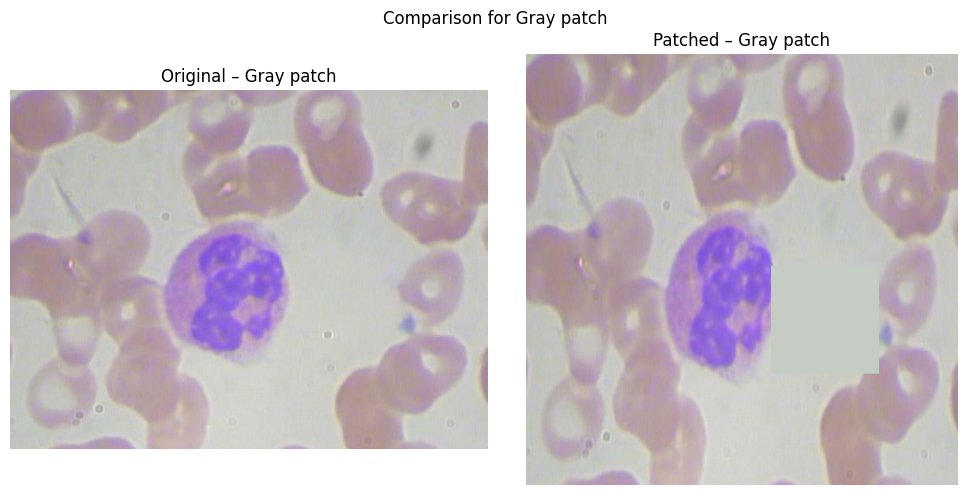

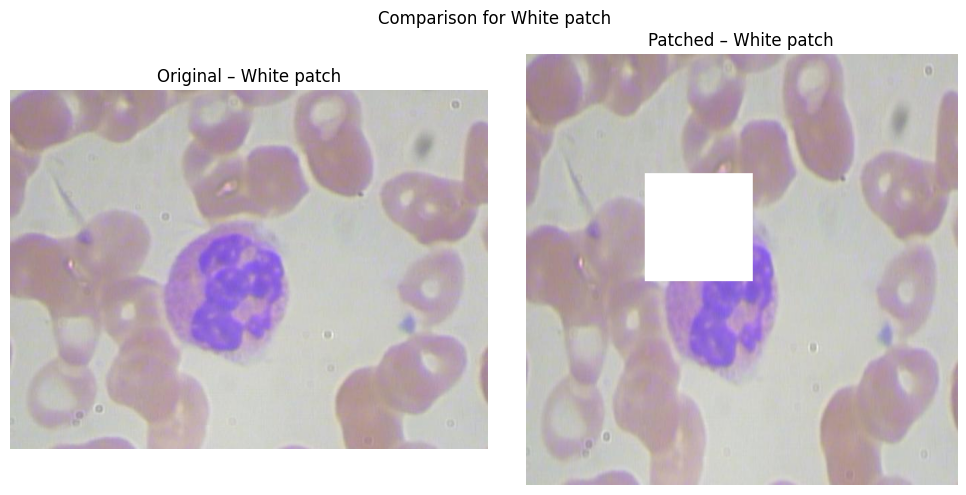

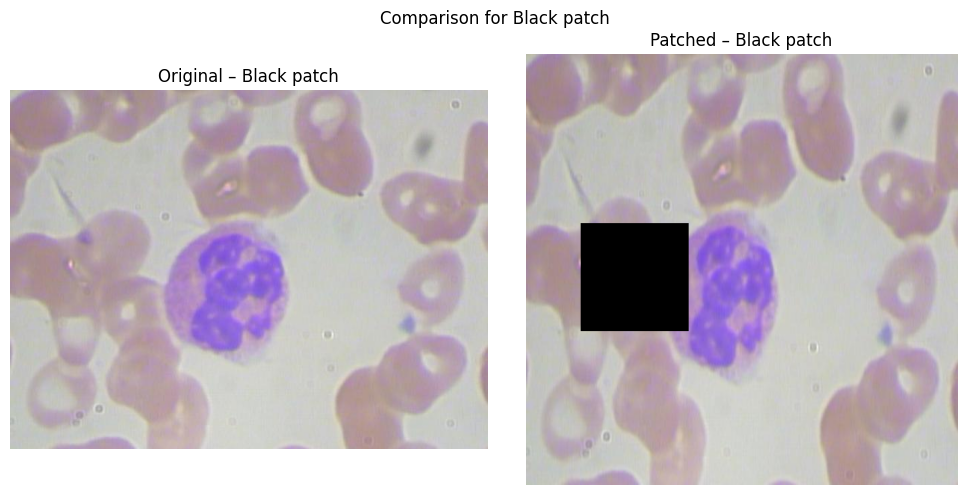

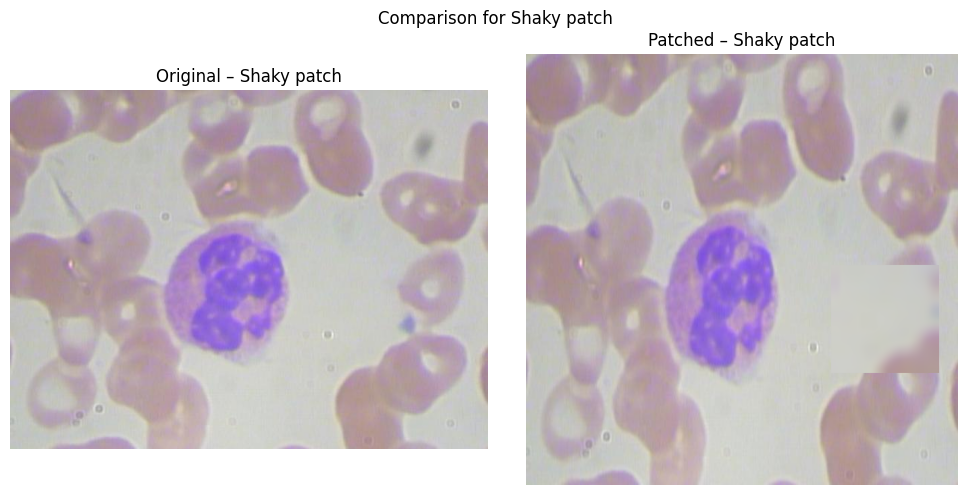

In [17]:
image_dir = '/content/drive/MyDrive/blood_cell_project/patch_visualizations/yolov8s'
display_patch_comparisons(image_dir)